<a href="https://colab.research.google.com/github/ai7dnn/2026-1-BDA/blob/main/code/14w_ch07_missingvalue_outlier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **빅데이터분석프로그래밍**

# 파이썬 설치 확인

In [1]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print(sys.version)
print(pd.__version__)
print(np.__version__)
print(sns.__version__)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
2.2.2
2.0.2
0.13.2


# 코랩에서 한글 처리

In [2]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
# 그림 선명하게
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 45.0 MB/s eta 0:00:00


In [3]:
# 데이터프레임의 소수점 이하 n(2)자리 출력 설정
pd.set_option('display.precision', 2)

In [4]:
plt.rcParams['figure.figsize'] = (4, 2)

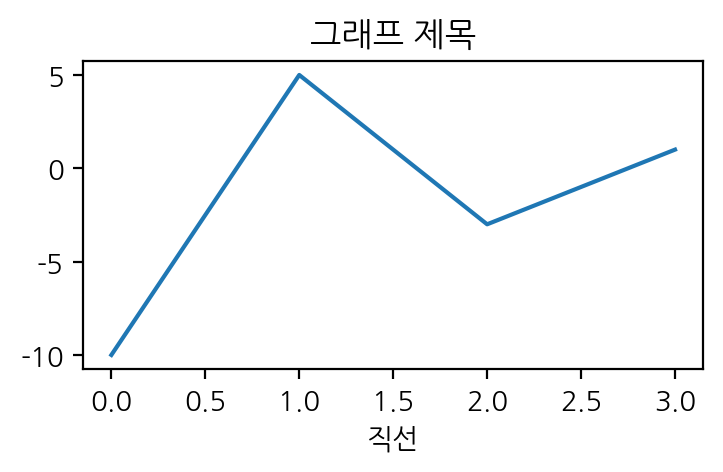

In [5]:
import matplotlib.pyplot as plt

plt.plot([-10, 5, -3, 1])
plt.title('그래프 제목')
plt.xlabel('직선')
plt.show()

In [6]:
from IPython.display import display_html
import inspect
import ast

def display_side_by_side(*dfs):
    titles = []

    try:
        caller_frame = inspect.currentframe().f_back
        call_line = inspect.getframeinfo(caller_frame).code_context[0].strip()

        tree = ast.parse(call_line)
        call = tree.body[0].value

        if isinstance(call, ast.Call):
            for arg in call.args:
                titles.append(ast.get_source_segment(call_line, arg))
    except:
        titles = [''] * len(dfs)

    if len(titles) < len(dfs):
        titles += [''] * (len(dfs) - len(titles))

    html_str = ''
    for df, title in zip(dfs, titles):
        html_str += f"""
        <div style="display:inline-block; vertical-align:top; margin-right:20px; text-align:center;">
            <div style="font-weight:bold; font-size:13px; margin-bottom:8px; text-align:center;">
                {title}
            </div>
            <div style="display:flex; justify-content:center;">
                {df.to_html()}
            </div>
        </div>
        """

    display_html(html_str, raw=True)

In [7]:
from IPython.display import display_html
import inspect
import ast

def display_series_side_by_side(*args):
    """여러 Series를 옆으로 나란히 표시하고,
    호출 시 사용한 표현식을 제목으로 위에 출력한다.
    """
    titles = []

    try:
        caller_frame = inspect.currentframe().f_back
        call_line = inspect.getframeinfo(caller_frame).code_context[0].strip()

        tree = ast.parse(call_line)
        call = tree.body[0].value

        if isinstance(call, ast.Call):
            for arg in call.args:
                titles.append(ast.get_source_segment(call_line, arg))
    except:
        titles = [''] * len(args)

    if len(titles) < len(args):
        titles += [''] * (len(args) - len(titles))

    html_str = ''
    for s, title in zip(args, titles):
        table_html = s.to_frame().to_html()

        html_str += f"""
        <div style="display:inline-block; vertical-align:top; margin-right:20px; text-align:center;">
            <div style="font-weight:bold; font-size:13px; margin-bottom:8px; text-align:center;">
                {title}
            </div>
            <div style="display:flex; justify-content:center;">
                {table_html}
            </div>
        </div>
        """

    display_html(html_str, raw=True)

## 수업에서 사용할 데이터를 다음 깃에서 복사
- https://github.com/ai7dnn/data.git

> #### 수업에서 파일 사용 시
> - 현재 하부 폴더: data
> - 파일: data/파일이름

In [8]:
!git clone https://github.com/ai7dnn/data.git

Cloning into 'data'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 50 (delta 12), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 5.71 MiB | 5.38 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [9]:
import pandas as pd

exam = pd.read_csv('data/exam.csv')
exam.head()

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65


# 07 데이터 정제  - 빠진 데이터, 이상한 데이터 제거하기

In [16]:
df = pd.DataFrame({'sex'   : ['M', 'F', np.nan, 'M', 'F'],
                   'score' : [5, 4, 3, 4, None]})
df

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN


In [11]:
df.score + 1

,score
0,6.0
1,5.0
2,4.0
3,5.0
4,NaN


#### 결측치 확인하기

In [17]:
pd.isna(df)

,sex,score
0,False,False
1,False,False
2,True,False
3,False,False
4,False,True


In [13]:
df.isna()

,sex,score
0,False,False
1,False,False
2,True,False
3,False,False
4,False,True


In [14]:
df.isnull()

,sex,score
0,False,False
1,False,False
2,True,False
3,False,False
4,False,True


In [19]:
display_side_by_side(df, pd.isna(df), pd.isnull(df), df.isna(), df.isnull())

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN
,sex,score
0,False,False
1,False,False
2,True,False
3,False,False


In [20]:
df.notna() # isnull() 반대

,sex,score
0,True,True
1,True,True
2,False,True
3,True,True
4,True,False


In [21]:
df.notnull()

,sex,score
0,True,True
1,True,True
2,False,True
3,True,True
4,True,False


In [22]:
display_side_by_side(df, pd.notna(df), pd.notnull(df), df.notna(), df.notnull())

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN
,sex,score
0,True,True
1,True,True
2,False,True
3,True,True


In [23]:
df.isna()

,sex,score
0,False,False
1,False,False
2,True,False
3,False,False
4,False,True


In [24]:
df.isna().sum()

,0
sex,1
score,1


In [26]:
df.isna().sum(axis=1)

,0
0,0
1,0
2,1
3,0
4,1


In [28]:
display_side_by_side(df.isna(), df.isna().sum().to_frame(), df.isna().sum(axis=0).to_frame(), df.isna().sum(axis=1).to_frame() )

df.isna()
 
 
 
 
 
 
 sex 
 score 
 
 
 
 
 0 
 False 
 False 
 
 
 1 
 False 
 False 
 
 
 2 
 True 
 False 
 
 
 3 
 False 
 False 
 
 
 4 
 False 
 True 
 
 
 
 
 
 
 
 
 df.isna().sum().to_frame()
 
 
 
 
 
 
 0 
 
 
 
 
 sex 
 1 
 
 
 score 
 1 
 
 
 
 
 
 
 
 
 df.isna().sum(axis=0).to_frame()
 
 
 
 
 
 
 0 
 
 
 
 
 sex 
 1 
 
 
 score 
 1 
 
 
 
 
 
 
 
 
 df.isna().sum(axis=1).to_frame()
 
 
 
 
 
 
 0 
 
 
 
 
 0 
 0 
 
 
 1 
 0 
 
 
 2 
 1 
 
 
 3 
 0 
 
 
 4 
 1

In [30]:
s = pd.Series([True, True, False, True])
s

,0
0,True
1,True
2,False
3,True


In [31]:
s.sum()

np.int64(3)

In [32]:
s.any()

np.True_

In [33]:
bool(s.any())

True

In [34]:
s.all()

np.False_

In [35]:
df

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN


In [36]:
df.isna()

,sex,score
0,False,False
1,False,False
2,True,False
3,False,False
4,False,True


In [37]:
df.isna().any(axis=0)

,0
sex,True
score,True


In [38]:
b = df.isna().any(axis=1)
b

,0
0,False
1,False
2,True
3,False
4,True


In [39]:
df[b] # NaN이 있는 행

,sex,score
2,NaN,3.0
4,F,NaN


In [40]:
# 적어도 NaN인 하나 있는 행을 추출
df[ df.isna().any(axis=1) ]

,sex,score
2,NaN,3.0
4,F,NaN


In [41]:
# NaN이 하나도 없는 행을 추출
df[ ~df.isna().any(axis=1) ]

,sex,score
0,M,5.0
1,F,4.0
3,M,4.0


In [42]:
# NaN이 하나도 없는 행을 추출
df[ df.notna().all(axis=1) ]

,sex,score
0,M,5.0
1,F,4.0
3,M,4.0


### mumpy.isnan() 함수: 속도가 빠름
- 수 값만 가능

In [43]:
df.score

,score
0,5.0
1,4.0
2,3.0
3,4.0
4,NaN


In [44]:
import numpy as np
np.isnan(df.score)

,score
0,False
1,False
2,False
3,False
4,True


In [45]:
pd.isna(df.score)

,score
0,False
1,False
2,False
3,False
4,True


In [46]:
display_series_side_by_side(np.isnan(df.score), pd.isna(df.score))

,score
0,False
1,False
2,False
3,False
4,True
,score
0,False
1,False
2,False
3,False


## 결측값 시각화
- [패키지 missingno](https://github.com/ResidentMario/missingno)

In [47]:
display_side_by_side(df, df.isnull())

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN
,sex,score
0,False,False
1,False,False
2,True,False
3,False,False


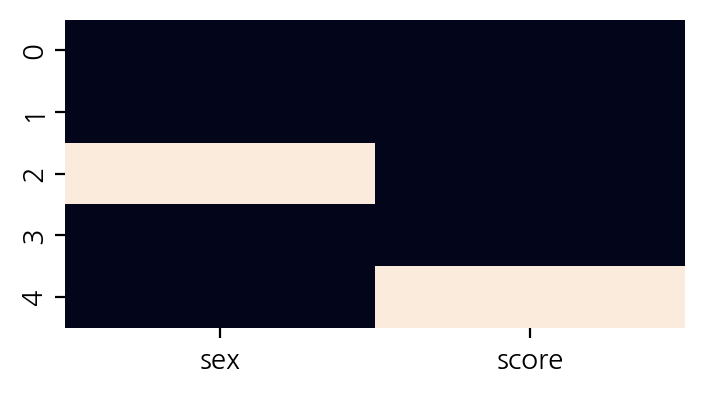

In [48]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False);

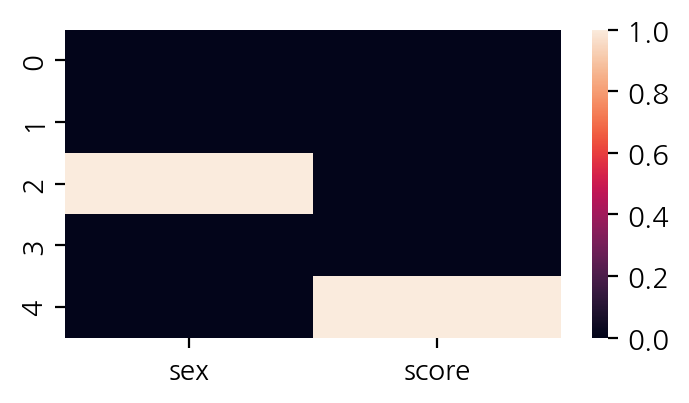

In [49]:
sns.heatmap(df.isnull());

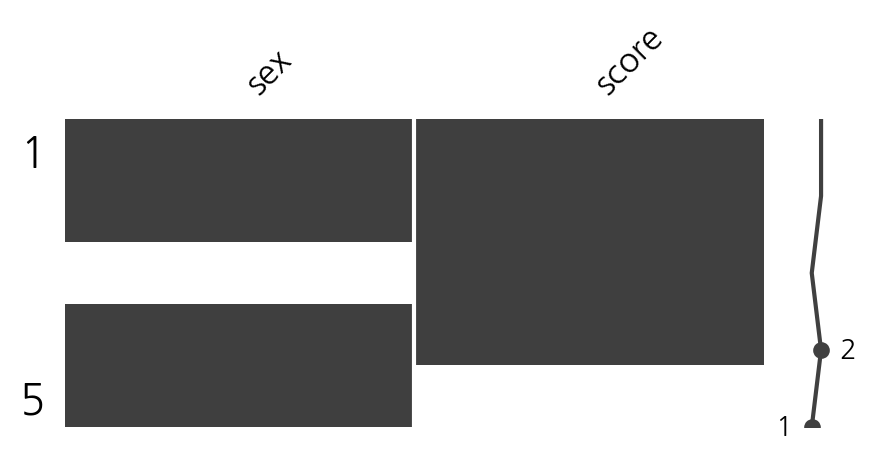

In [51]:
import missingno as msno
# 가로 5인치, 세로 2인치 크기로 지정
msno.matrix(df, figsize=(5, 2), fontsize=12);

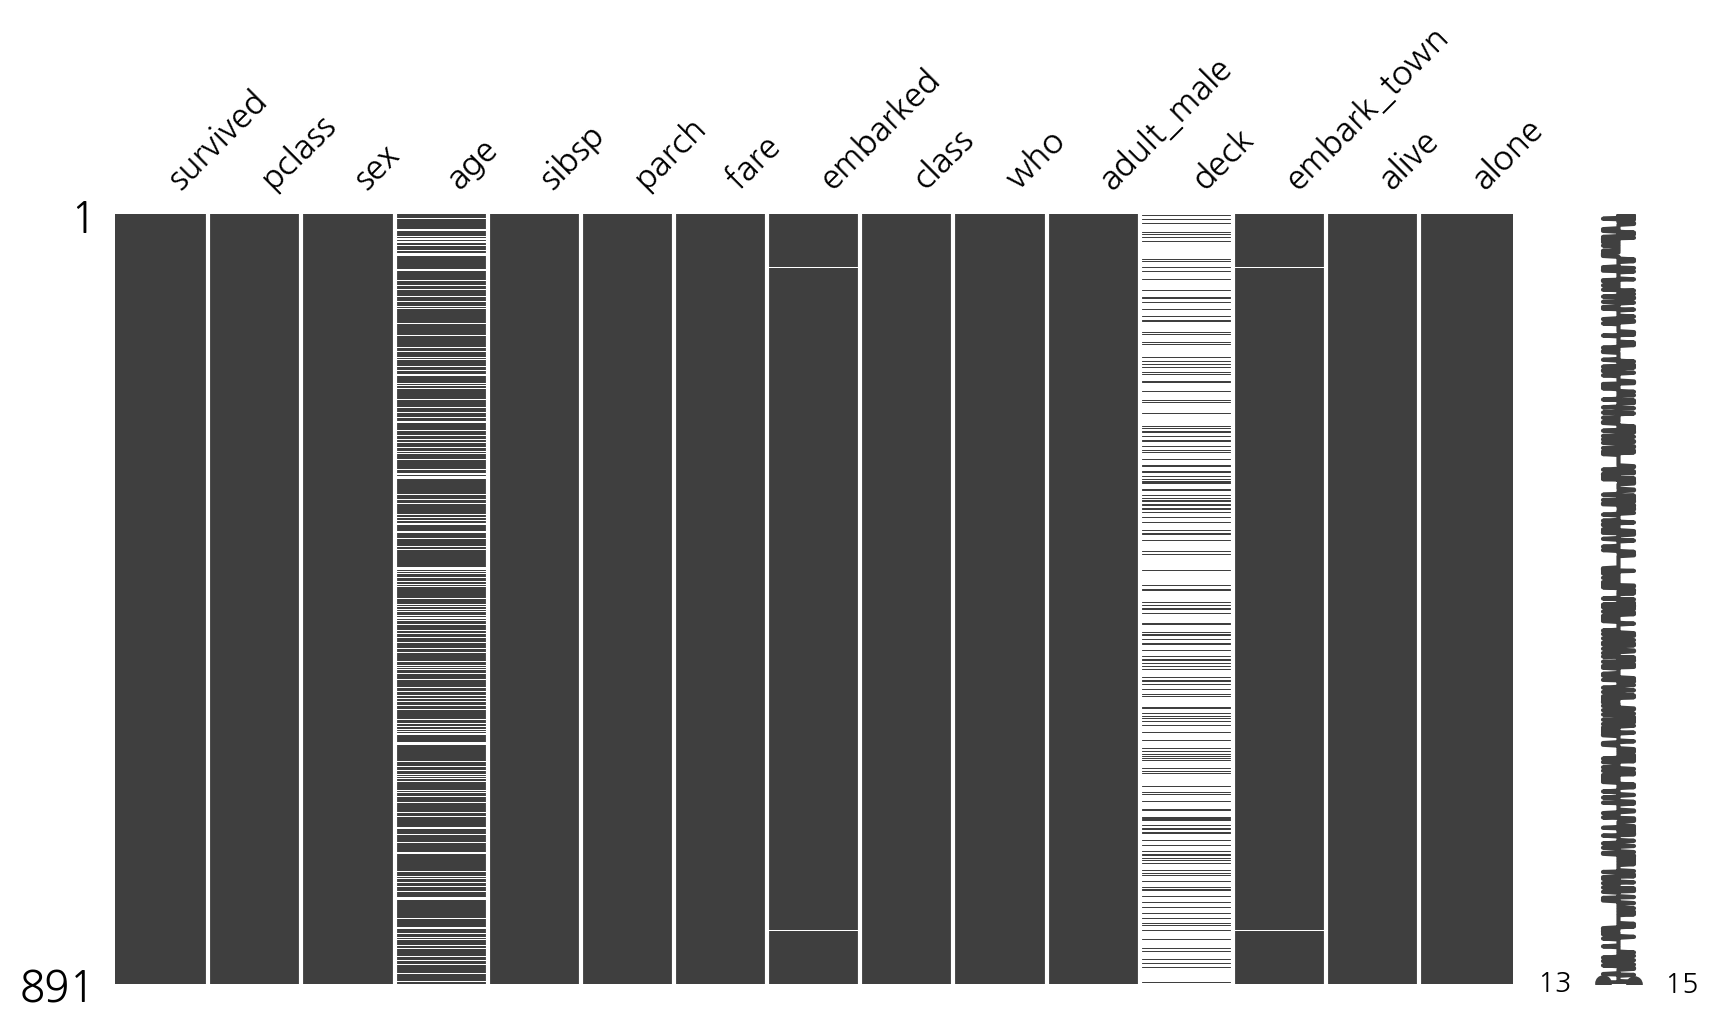

In [52]:
tdf = sns.load_dataset('titanic')
msno.matrix(tdf, figsize=(10, 5), fontsize=12);

In [53]:
tdf2 = tdf.sample(20)
tdf2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
111,0,3,female,14.5,1,0,14.45,C,Third,child,False,NaN,Cherbourg,no,False
539,1,1,female,22.0,0,2,49.50,C,First,woman,False,B,Cherbourg,yes,False
495,0,3,male,NaN,0,0,14.46,C,Third,man,True,NaN,Cherbourg,no,True
235,0,3,female,NaN,0,0,7.55,S,Third,woman,False,NaN,Southampton,no,True
663,0,3,male,36.0,0,0,7.50,S,Third,man,True,NaN,Southampton,no,True
298,1,1,male,NaN,0,0,30.50,S,First,man,True,C,Southampton,yes,True
828,1,3,male,NaN,0,0,7.75,Q,Third,man,True,NaN,Queenstown,yes,True
479,1,3,female,2.0,0,1,12.29,S,Third,child,False,NaN,Southampton,yes,False
513,1,1,female,54.0,1,0,59.40,C,First,woman,False,NaN,Cherbourg,yes,False
134,0,2,male,25.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True


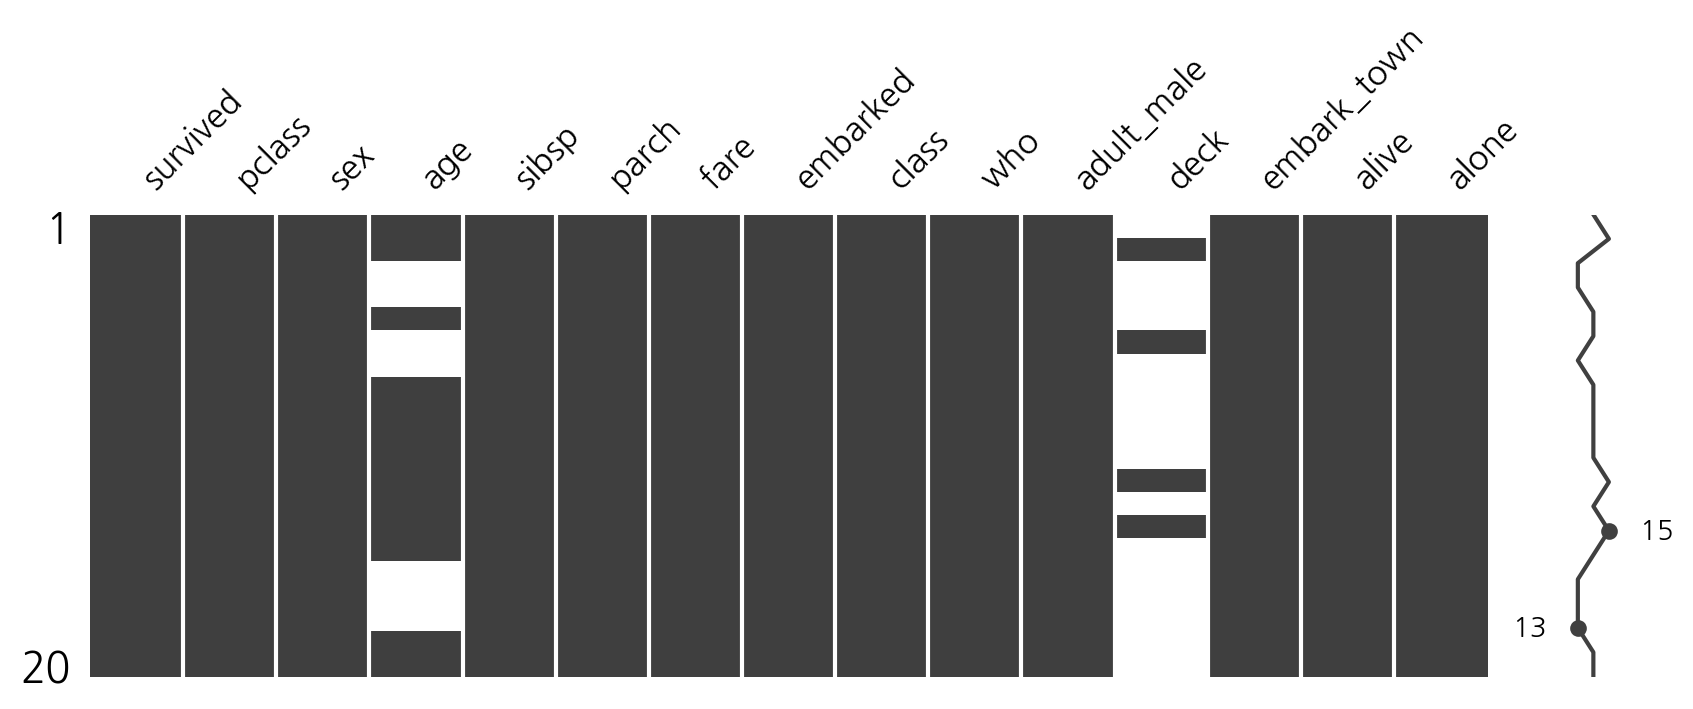

In [54]:
msno.matrix(tdf2, figsize=(10, 3), fontsize=12);

- 오른쪽의 스파크라인은 각 행에서 결측값이 없는 수를 연결한 라인 모양
    - 행마다 15개중 결측값(NaN)이 아닌 정상적인 데이터의 수를 나타냄
    - 15는 모두 정상값, 13은 2개가 결측값이 있는 행
    - 그 점을 다음 행과 연결한 선

In [55]:
# 열 embarked가 NaN인 행 추출
tdf[ tdf.embarked.isna() ]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True


In [56]:
# 두 열, age, deck이 모두 NaN인 행 추출
tdf[ (tdf.age.isna()) & (tdf.deck.isna()) ]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,0,3,male,NaN,0,0,8.46,Q,Third,man,True,NaN,Queenstown,no,True
17,1,2,male,NaN,0,0,13.00,S,Second,man,True,NaN,Southampton,yes,True
19,1,3,female,NaN,0,0,7.22,C,Third,woman,False,NaN,Cherbourg,yes,True
26,0,3,male,NaN,0,0,7.22,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.88,Q,Third,woman,False,NaN,Queenstown,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.23,C,Third,man,True,NaN,Cherbourg,no,True
863,0,3,female,NaN,8,2,69.55,S,Third,woman,False,NaN,Southampton,no,False
868,0,3,male,NaN,0,0,9.50,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.90,S,Third,man,True,NaN,Southampton,no,True


In [57]:
# 세 개 열, age, deck, embark_town이 모두 NaN인 행 추출
tdf[ (tdf.age.isna()) & (tdf.deck.isna()) & (tdf.embark_town.isna()) ]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


In [58]:
# 최소한 1개의 NaN에 있는 행 추출
tdf[ tdf.isna().any(axis=1) ]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.46,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.07,S,Third,child,False,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,3,male,25.0,0,0,7.05,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.12,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False


In [59]:
# 최소한 1개의 NaN에 있는 행 추출
tdf.drop( tdf.dropna().index )

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.46,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.07,S,Third,child,False,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,3,male,25.0,0,0,7.05,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.12,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False


In [60]:
# 모든 열 값이 결측값이 아닌 행 추출
tdf.dropna()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.86,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.70,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.55,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.55,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.00,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.16,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True


In [61]:
tdf.dropna().shape[0] + tdf.drop( tdf.dropna().index ).shape[0]

891

In [62]:
tdf.shape[0]

891

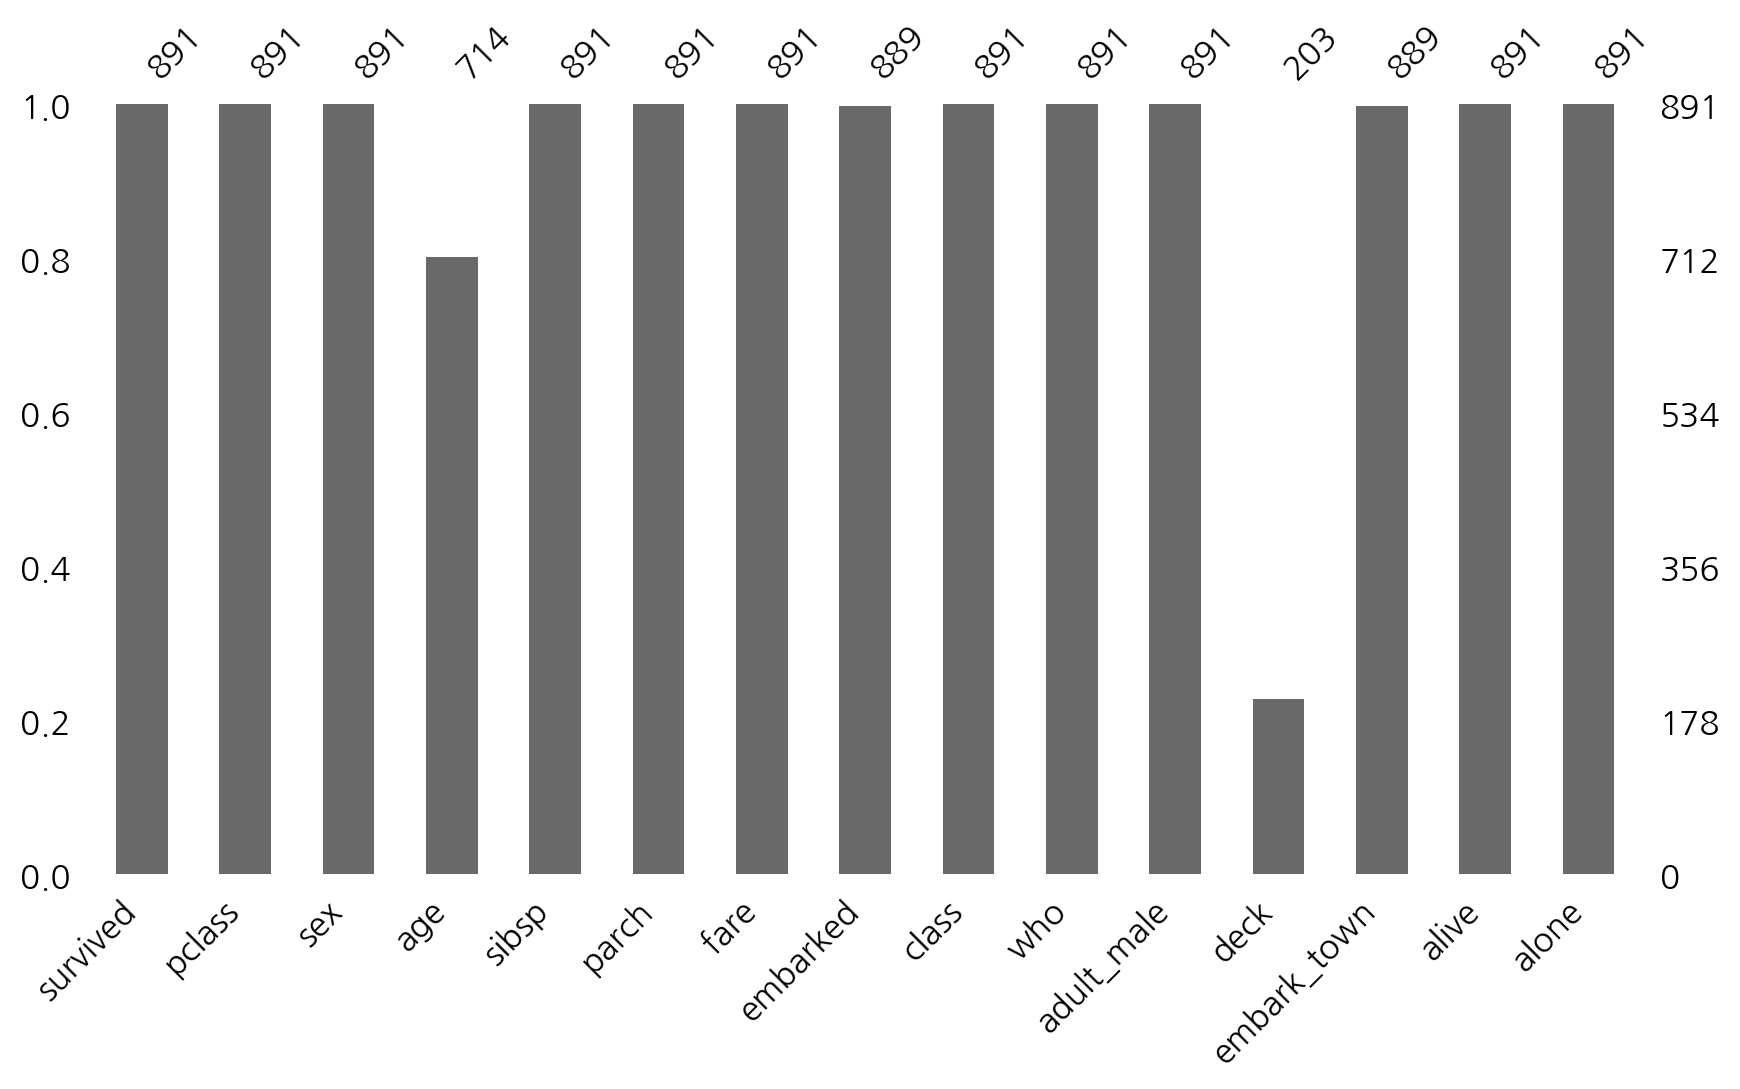

In [63]:
msno.bar(tdf, figsize=(10, 5), fontsize=12); # label_rotation=45

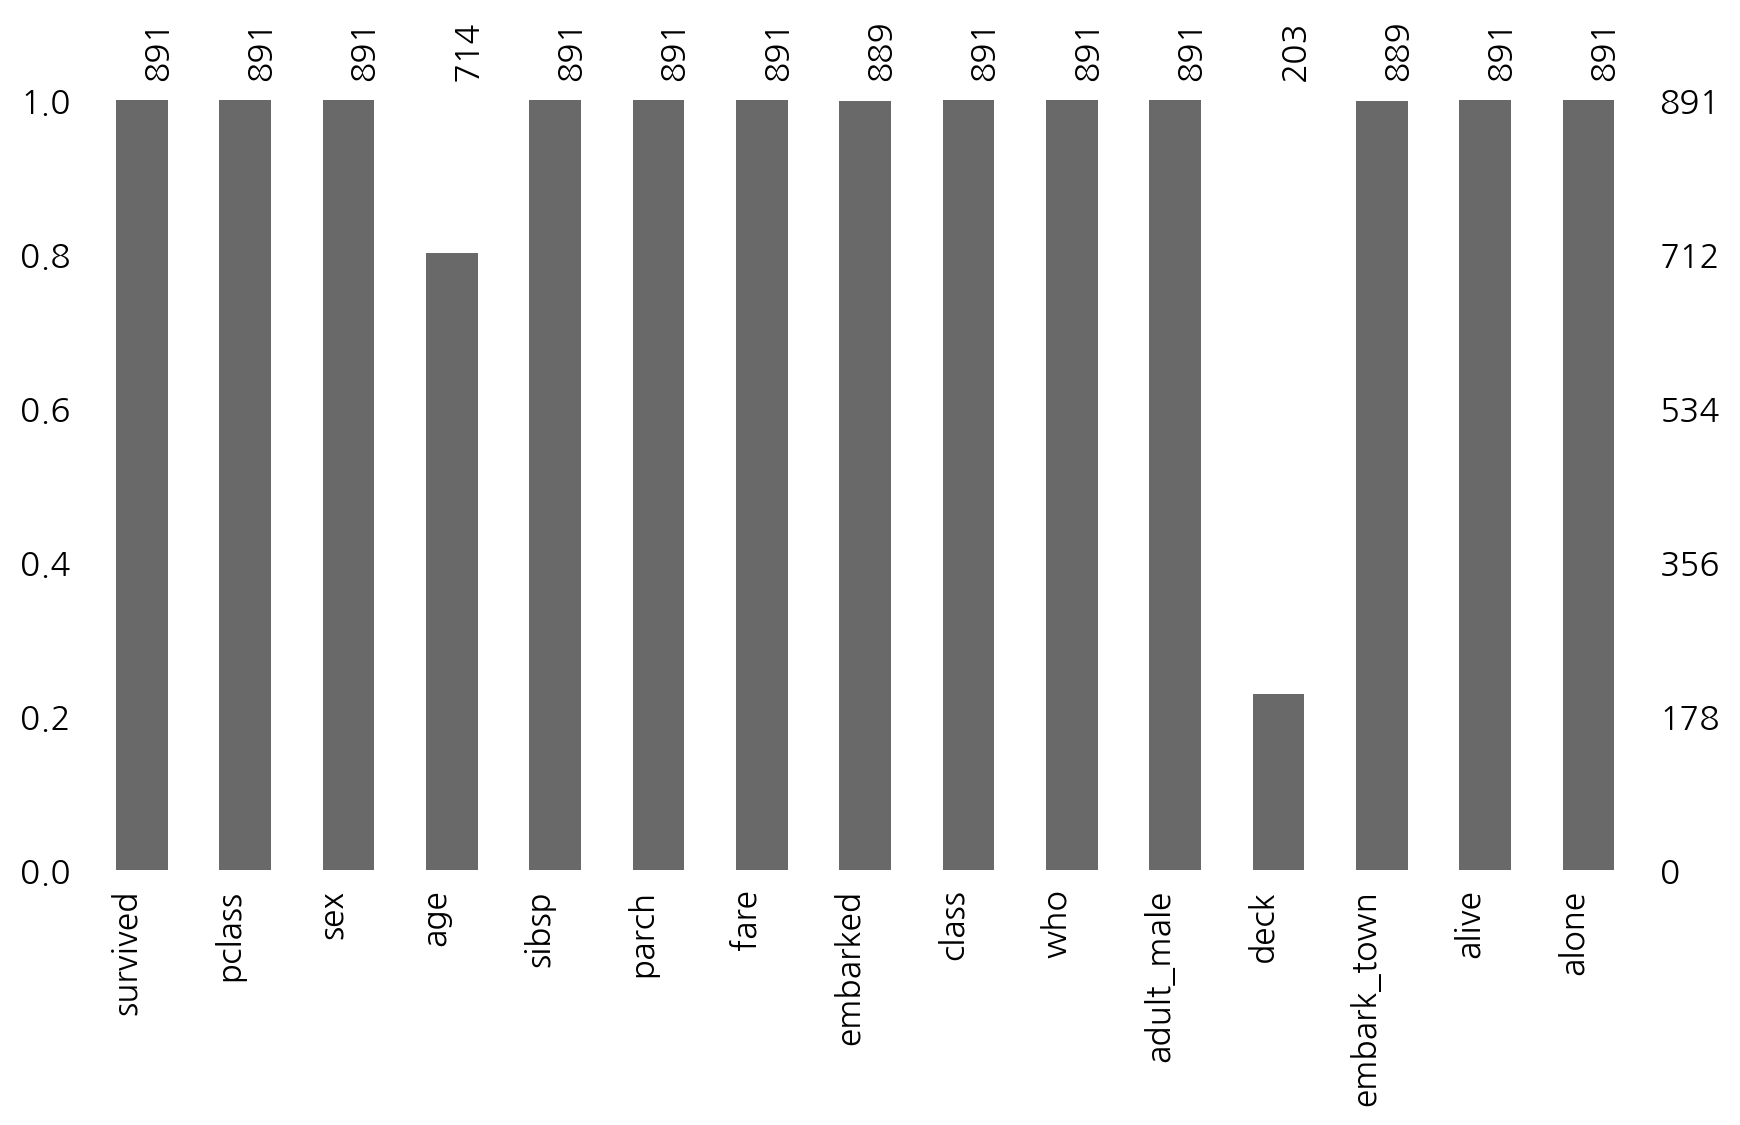

In [64]:
msno.bar(tdf, figsize=(10, 5), fontsize=12, label_rotation=90);

### 결측치 제거하기

In [65]:
df

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN


In [66]:
df.dropna()

,sex,score
0,M,5.0
1,F,4.0
3,M,4.0


### 인자 axis (제거할 방향 설정)
- 결측치를 만났을 때, 행(Row)을 지울지 열(Column)을 지울지 결정합니다.
- axis=0 또는 axis='index' (기본값): 결측치가 포함된 행을 통째로 지웁니다.
- axis=1 또는 axis='columns' : 결측치가 포함된 열을 통째로 지웁니다.

### 인자 subset (특정 컬럼/인덱스만 조준)
- 데이터프레임 전체를 검사하는 것이 아니라, 지정한 특정 열(또는 행)들만 검사하여 결측치를 지웁니다. 실무에서 가장 유용하게 쓰이는 인자입니다.
- 예시: df.dropna(subset=['Age', 'Score'])
    - 다른 컬럼에 결측치가 아무리 많아도 무시하고, 오직 'Age'와 'Score' 컬럼에 결측치가 있는 행만 골라서 지웁니다.

In [67]:
df.dropna(subset=['sex'])

,sex,score
0,M,5.0
1,F,4.0
3,M,4.0
4,F,NaN


In [68]:
display_side_by_side( df, df.dropna(subset=['sex']), df.dropna(subset=['score']) )

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN
,sex,score
0,M,5.0
1,F,4.0
3,M,4.0
4,F,NaN


In [69]:
df_nomiss = df.dropna(subset = ['score'])  # score 결측치 제거된 데이터 만들기
df_nomiss

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0


In [70]:
df_nomiss['score'] + 1                     # score로 연산

,score
0,6.0
1,5.0
2,4.0
3,5.0


In [71]:
df.dropna(subset=['sex'], axis=0)

,sex,score
0,M,5.0
1,F,4.0
3,M,4.0
4,F,NaN


In [72]:
# 행 2에 NaN이 있으면 열을 제거
df.dropna(subset = [2], axis = 1)

,score
0,5.0
1,4.0
2,3.0
3,4.0
4,NaN


In [73]:
display_side_by_side(df, df.dropna(subset = [2], axis = 1), df.dropna(subset = [4], axis = 1))

df
 
 
 
 
 
 
 sex 
 score 
 
 
 
 
 0 
 M 
 5.0 
 
 
 1 
 F 
 4.0 
 
 
 2 
 NaN 
 3.0 
 
 
 3 
 M 
 4.0 
 
 
 4 
 F 
 NaN 
 
 
 
 
 
 
 
 
 df.dropna(subset = [2], axis = 1)
 
 
 
 
 
 
 score 
 
 
 
 
 0 
 5.0 
 
 
 1 
 4.0 
 
 
 2 
 3.0 
 
 
 3 
 4.0 
 
 
 4 
 NaN 
 
 
 
 
 
 
 
 
 df.dropna(subset = [4], axis = 1)
 
 
 
 
 
 
 sex 
 
 
 
 
 0 
 M 
 
 
 1 
 F 
 
 
 2 
 NaN 
 
 
 3 
 M 
 
 
 4 
 F

In [74]:
# 행 3에 NaN이 있으면 열을 제거
df.dropna(subset = [3], axis = 1)

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN


In [75]:
# 모든 열에서 하나라도 결측값이 있으면 제거
df.dropna(axis = 1)

""
0
1
2
3
4


In [76]:
df.dropna(axis = 1).empty

True

In [77]:
df

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN


In [78]:
df['score'].mean() # 결측값은 제거(무시)하고 계산

np.float64(4.0)

In [79]:
df['score'].sum() # 결측값은 제거(무시)하고 계산

np.float64(16.0)

In [84]:
# 결측값은 제거(무시)하고 계산
df.groupby('sex').agg(mean_score = ('score', 'mean'),
                      sum_score  = ('score', 'sum'))

,mean_score,sum_score
sex,,
F,4.0,4.0
M,4.5,9.0


### pandas 문서: df.dropna()

In [85]:
df = pd.DataFrame({"name": ['Alfred', 'Batman', 'Catwoman', np.nan],
                   "toy": [np.nan, 'Batmobile', 'Bullwhip', np.nan],
                   "born": [pd.NaT, pd.Timestamp("1940-04-25"), pd.NaT, pd.NaT]})
df

,name,toy,born
0,Alfred,NaN,NaT
1,Batman,Batmobile,1940-04-25
2,Catwoman,Bullwhip,NaT
3,NaN,NaN,NaT


In [86]:
df.isna()

,name,toy,born
0,False,True,True
1,False,False,False
2,False,False,True
3,True,True,True


In [87]:
df.dropna()

,name,toy,born
1,Batman,Batmobile,1940-04-25


In [89]:
# 모든 값이 null이 아닌 행만 출력
df[ df.notnull().all(axis=1) ]

,name,toy,born
1,Batman,Batmobile,1940-04-25


In [90]:
# 결측값이 없는 행 출력
display_side_by_side(df, df.dropna(), df[ df.notnull().all(axis=1) ])

,name,toy,born
0,Alfred,NaN,NaT
1,Batman,Batmobile,1940-04-25
2,Catwoman,Bullwhip,NaT
3,NaN,NaN,NaT
,name,toy,born
1,Batman,Batmobile,1940-04-25
,name,toy,born
1,Batman,Batmobile,1940-04-25


In [91]:
# 결측값이 있는 행 출력
display_side_by_side(df, df.drop( df.dropna().index ), df[ df.isnull().any(axis=1) ])

,name,toy,born
0,Alfred,NaN,NaT
1,Batman,Batmobile,1940-04-25
2,Catwoman,Bullwhip,NaT
3,NaN,NaN,NaT
,name,toy,born
0,Alfred,NaN,NaT
2,Catwoman,Bullwhip,NaT
3,NaN,NaN,NaT
,name,toy,born
0,Alfred,NaN,NaT


In [92]:
df.dropna(axis='columns') # 아무 것도 없는 빈 데이터프레임

""
0
1
2
3


In [93]:
# 모든 값이 NaN인 경우, 행 제거
display_side_by_side(df, df.dropna(how='all'), df[ ~df.isna().all(axis=1) ])

,name,toy,born
0,Alfred,NaN,NaT
1,Batman,Batmobile,1940-04-25
2,Catwoman,Bullwhip,NaT
3,NaN,NaN,NaT
,name,toy,born
0,Alfred,NaN,NaT
1,Batman,Batmobile,1940-04-25
2,Catwoman,Bullwhip,NaT
,name,toy,born
0,Alfred,NaN,NaT


In [94]:
# 하나라도 NaN인 경우, 행 제거
display_side_by_side(df, df.dropna(how='any'), df.dropna(), df[ df.notna().all(axis=1) ])

,name,toy,born
0,Alfred,NaN,NaT
1,Batman,Batmobile,1940-04-25
2,Catwoman,Bullwhip,NaT
3,NaN,NaN,NaT
,name,toy,born
1,Batman,Batmobile,1940-04-25
,name,toy,born
1,Batman,Batmobile,1940-04-25
,name,toy,born
1,Batman,Batmobile,1940-04-25


### 결측치 대체하기

In [95]:
exam = pd.read_csv('data/exam.csv')      # 데이터 불러오기
exam.loc[[2, 7, 14], ['math']] = np.nan  # 2, 7, 14행의 math에 NaN 할당
exam

,id,nclass,math,english,science
0,1,1,50.0,98,50
1,2,1,60.0,97,60
2,3,1,NaN,86,78
3,4,1,30.0,98,58
4,5,2,25.0,80,65
5,6,2,50.0,89,98
6,7,2,80.0,90,45
7,8,2,NaN,78,25
8,9,3,20.0,98,15
9,10,3,50.0,98,45


In [96]:
exam.loc[[2, 7, 14], ['math']]

,math
2,NaN
7,NaN
14,NaN


In [97]:
exam['math'].mean()

np.float64(55.23529411764706)

In [98]:
round(float(exam['math'].mean()), 2)

55.24

### 결측값 채워넣기 fillna()

In [ ]:
exam['math'] = exam['math'].fillna(100)  # math가 NaN이면 55로 대체
exam                                     # 출력

,id,nclass,math,english,science
0,1,1,50.0,98,50
1,2,1,60.0,97,60
2,3,1,100.0,86,78
3,4,1,30.0,98,58
4,5,2,25.0,80,65
5,6,2,50.0,89,98
6,7,2,80.0,90,45
7,8,2,100.0,78,25
8,9,3,20.0,98,15
9,10,3,50.0,98,45


In [ ]:
exam.loc[[2, 7, 14], ['math']] = np.nan  # 2, 7, 14행의 math에 NaN 할당
exam

,id,nclass,math,english,science
0,1,1,50.0,98,50
1,2,1,60.0,97,60
2,3,1,NaN,86,78
3,4,1,30.0,98,58
4,5,2,25.0,80,65
5,6,2,50.0,89,98
6,7,2,80.0,90,45
7,8,2,NaN,78,25
8,9,3,20.0,98,15
9,10,3,50.0,98,45


In [ ]:
pd.set_option('display.precision', 2)
exam['math'] = exam['math'].fillna(exam['math'].mean())  # math가 NaN이면 55로 대체
exam

,id,nclass,math,english,science
0,1,1,50.00,98,50
1,2,1,60.00,97,60
2,3,1,55.24,86,78
3,4,1,30.00,98,58
4,5,2,25.00,80,65
5,6,2,50.00,89,98
6,7,2,80.00,90,45
7,8,2,55.24,78,25
8,9,3,20.00,98,15
9,10,3,50.00,98,45


### 이상값

In [99]:
import pandas as pd
mpg = pd.read_csv('data/mpg.csv')
mpg.sample(5)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
95,ford,mustang,4.6,1999,8,manual(m5),r,15,22,r,subcompact
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
176,toyota,4runner 4wd,3.4,1999,6,manual(m5),4,15,17,r,suv
214,volkswagen,jetta,2.0,1999,4,auto(l4),f,19,26,r,compact
144,nissan,altima,2.5,2008,4,manual(m6),f,23,32,r,midsize


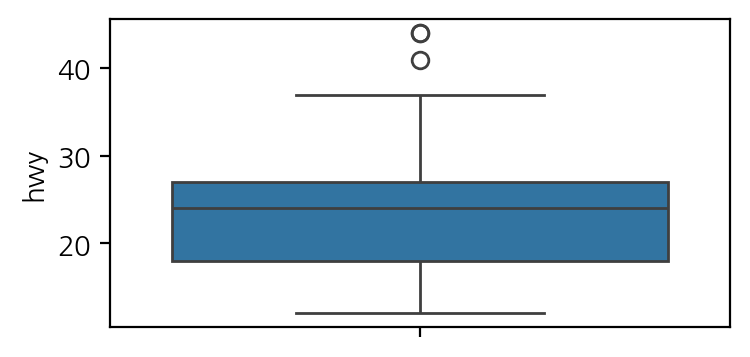

In [ ]:
sns.boxplot(mpg, y = 'hwy');

### 박스상자의 구성요소
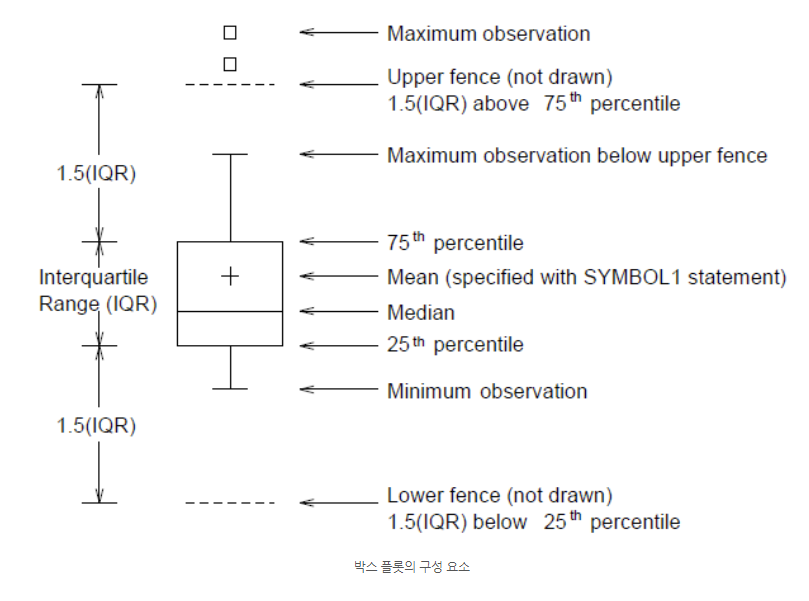

## 종료